# Building a gene network from the IDR and STRINGdb
This notebook exemplifies how to build Figure 2 of the paper
using the IDR API.

### Dependencies
 * [Matplotlib](http://matplotlib.org/)
 * [NumPy](http://www.numpy.org/)
 * [Pandas](http://pandas.pydata.org/)
 * [NetworkX](https://networkx.github.io/)
 * [Py2Cytoscape](https://pypi.python.org/pypi/py2cytoscape)
 * [Requests](http://docs.python-requests.org/)
 

In [1]:
from IPython import get_ipython
import warnings

import requests
from pandas import DataFrame
from pandas import read_csv
from pandas import concat
from io import StringIO

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from bokeh.models import ColumnDataSource
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool
from bokeh.palettes import brewer

output_notebook()
get_ipython().run_line_magic('matplotlib', 'inline')

Loading BokehJS ...

In [2]:
IDR_BASE_URL = "https://idr.openmicroscopy.org"
INDEX_PAGE = f"{IDR_BASE_URL}/webclient/?experimenter=-1"
# create http session
with requests.Session() as session:
    request = requests.Request('GET', INDEX_PAGE)
    prepped = session.prepare_request(request)
    response = session.send(prepped)
    if response.status_code != 200:
        response.raise_for_status()

### Method definitions

In [3]:
def getBulkAnnotationAsDf(screenID):
    # list annotations...
    url = f"{IDR_BASE_URL}/webclient/api/annotations/?type=file&screen={screenID}"
    json_data = session.get(url).json()
    # look for name = "bulk_annotations"
    file_id = None
    for ann in json_data["annotations"]:
        if ann.get("file", {}).get("name") == "bulk_annotations":
            file_id = ann["file"]["id"]
            break

    print("file_id", file_id)
    if file_id is None:
        return
    limit = 1000
    offset = 0
    row_count = None
    data = []
    while (row_count is None or offset < row_count):
        url = f"{IDR_BASE_URL}/webclient/omero_table/{file_id}/json/?limit={limit}&offset={offset}"
        json_data = session.get(url).json()
        row_count = json_data["meta"]["totalCount"]
        column_names = json_data["data"]["columns"]
        data.extend(json_data["data"]["rows"])
        offset += limit
        print(f"loaded {offset}/{row_count} rows")

    dfAnn = DataFrame(data)
    dfAnn.columns = column_names
    return dfAnn


In [3]:
def getGenesFromPhenotype(df, phTerm):
    # all gene from bulk_annotation 'df' annotated with CMPO term 'phTerm'
    colElong = []
    for col in df.columns:
        if 'Term Accession' in col:
            if phTerm in df[col].unique():
                colElong.append(col)

    dfElong = concat([df[df[col] != ''] for col in colElong])
    return dfElong['Gene Identifier'].unique()


## Querying the IDR
We will download the annotations for the three screens under study
as panda DataFrames, and sub-select the genes from each which are
annotated with the phenotype we are looking for, CMPO_0000077 a.k.a.
'elongated cell phenotype'.
The next step is to build, from that list, a list of IDs we can
query the STRING database with. The translation table was built offline
using biomart and pombase.

In [5]:
# CMPO term to look for
ph_term = 'CMPO_0000077'

# ids of screens:
# sc_id = 3  # Graml et al.
# sc_id = 206  # Rohn et al., B
# sc_id = 1202  # Fuchs et al., B

screens = [3, 206, 1202]

genes = []
for sc_id in screens:
    print('loading ' + str(sc_id))

    # loading bulk_annotations of screens as dataframes
    df = getBulkAnnotationAsDf(sc_id)
    # unique genes with CPMO term
    cur = getGenesFromPhenotype(df, ph_term)
    print('got ' + str(len(cur)) + ' genes')
    genes.extend(cur)

loading 3
file_id 14209154
loaded 1000/18432 rows
loaded 2000/18432 rows
loaded 3000/18432 rows
loaded 4000/18432 rows
loaded 5000/18432 rows
loaded 6000/18432 rows
loaded 7000/18432 rows
loaded 8000/18432 rows
loaded 9000/18432 rows
loaded 10000/18432 rows
loaded 11000/18432 rows
loaded 12000/18432 rows
loaded 13000/18432 rows
loaded 14000/18432 rows
loaded 15000/18432 rows
loaded 16000/18432 rows
loaded 17000/18432 rows
loaded 18000/18432 rows
loaded 19000/18432 rows
got 39 genes
loading 206
file_id 15026339
loaded 1000/4224 rows
loaded 2000/4224 rows
loaded 3000/4224 rows
loaded 4000/4224 rows
loaded 5000/4224 rows
got 72 genes
loading 1202
file_id 44583136
loaded 1000/26112 rows
loaded 2000/26112 rows
loaded 3000/26112 rows
loaded 4000/26112 rows
loaded 5000/26112 rows
loaded 6000/26112 rows
loaded 7000/26112 rows
loaded 8000/26112 rows
loaded 9000/26112 rows
loaded 10000/26112 rows
loaded 11000/26112 rows
loaded 12000/26112 rows
loaded 13000/26112 rows
loaded 14000/26112 rows
load

### Translation

In [7]:
# The table was built offline using biomart
dfTrans = read_csv('https://raw.githubusercontent.com/IDR/idr-notebooks/master/includes/TableOfGenesWithElongatedCellPhenotype.csv')

# extract IDs
key = 'Human Ortholog Ensembl 84'
genesE84 = concat([dfTrans[dfTrans['Screen GeneID'] == x][key] for x in genes])
genesE84 = genesE84[genesE84 != '(null)']

print(genes[:10])
print(genesE84.head(10))

['SPAC3G9.08', 'SPCC970.10c', 'SPCC553.08c', 'SPAC16C9.05', 'SPAC30.02c', 'SPAC3H8.05c', 'SPCC306.04c', 'SPCC338.16', 'SPCP1E11.06', 'SPAC1556.01c']
15    ENSG00000071243
16    ENSG00000111653
17    ENSG00000168395
18    ENSG00000168556
47    ENSG00000103549
48    ENSG00000155827
44    ENSG00000140598
2     ENSG00000109118
11    ENSG00000198841
40    ENSG00000099381
Name: Human Ortholog Ensembl 84, dtype: str


### REST query of STRINGdb
We use the STRINGdb REST API to get all the known interactions
of all of our genes.

In [8]:
# Building STRINGdb REST api query
url = 'http://string-db.org/api/psi-mi-tab/interaction_partners?species=9606&limit=5&identifiers='
# genesE84 = genesE84[:10]
for g in genesE84:
    url = url + g + '%0d'
res = requests.get(url)

In [9]:
df_original = read_csv(StringIO(res.text), sep='\t', header=None)
df_full = df_original.replace(to_replace ='string:', value = '', regex = True)
df = df_full[:int(len(df_full.index)/5)]
df_full.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,9606.ENSP00000320566,9606.ENSP00000340330,ING3,KAT5,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.999|coexpression:0.049|labexperim...
1,9606.ENSP00000320566,9606.ENSP00000331310,ING3,MORF4L1,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.999|coexpression:0.090|labexperim...
2,9606.ENSP00000320566,9606.ENSP00000362166,ING3,MEAF6,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.998|coexpression:0.066|labexperim...
3,9606.ENSP00000320566,9606.ENSP00000361363,ING3,DMAP1,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.998|coexpression:0.067|labexperim...
4,9606.ENSP00000320566,9606.ENSP00000352925,ING3,TRRAP,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.998|coexpression:0.134|labexperim...
5,9606.ENSP00000380024,9606.ENSP00000259021,ING4,KAT7,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.999|coexpression:0.042|labexperim...
6,9606.ENSP00000380024,9606.ENSP00000362166,ING4,MEAF6,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.999|coexpression:0.092|labexperim...
7,9606.ENSP00000380024,9606.ENSP00000226319,ING4,JADE1,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.998|coexpression:0.049|labexperim...
8,9606.ENSP00000380024,9606.ENSP00000355657,ING4,H3-4,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.986|coexpression:0.052|labexperim...
9,9606.ENSP00000380024,9606.ENSP00000352252,ING4,H3C12,-,-,-,-,-,taxid:9606,taxid:9606,-,-,-,confidence:0.985|coexpression:0.052|labexperim...


### Some displays

#### A. NetworkX

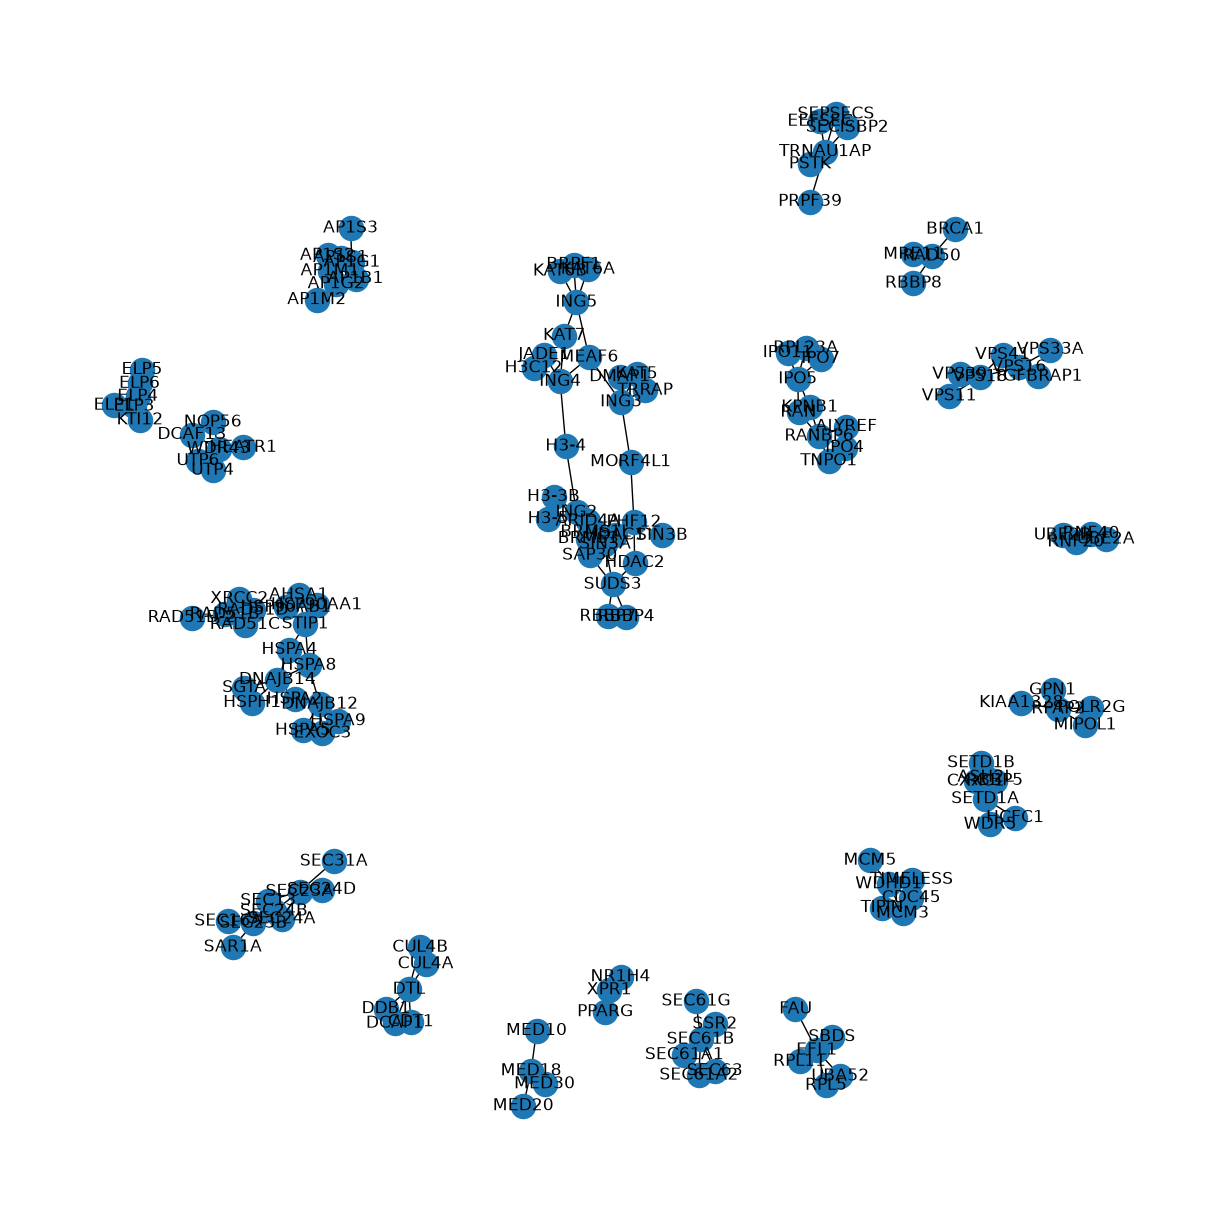

In [9]:
warnings.filterwarnings('ignore')
g = nx.from_pandas_edgelist(df, 2, 3)
plt.figure(figsize=(12, 12))
nx.draw_spring(g, with_labels=True)

#### B. Bokeh

In [14]:
# Use spring layout from networkx for display
pts = nx.spring_layout(g)

TOOLS = "tap,pan,wheel_zoom,reset"
p = figure(width=800, height=800, title="My chart", tools=TOOLS)

# color certain genes of interest
# comment out this section if not needed
colors = np.ones(len(g.nodes()))
colors[[x == 'ASH2L' for x in pts.keys()]] = 4
colors[[x == 'SETD1A' for x in pts.keys()]] = 2
colors[[x == 'SETD1B' for x in pts.keys()]] = 2
cm = brewer['Set1'][5]
colors = [cm[int(x)] for x in colors]
names = list(pts.keys())
cntr = 0
for x in pts.values():
    cir = p.circle(x=x[0], y=x[1], radius=.01,
                   color=colors[cntr], name=names[cntr])
    cntr = cntr + 1

# uncomment next line if not
# coloring genes of interest
# cir=p.circle('x','y',source=sourceNode,radius=.01)
sourceEdges = ColumnDataSource(
    data=dict(
        x1=[pts[x[0]][0] for x in g.edges()],
        y1=[pts[x[0]][1] for x in g.edges()],
        x2=[pts[x[1]][0] for x in g.edges()],
        y2=[pts[x[1]][1] for x in g.edges()]
    ))
seg = p.segment('x1', 'y1', 'x2', 'y2', source=sourceEdges)
hover = HoverTool(
        tooltips=[
            ("Name", "@names"),
        ]
    )
p.add_tools(hover)

show(p)


### License (BSD 2-Clause)¶ 
Copyright (C) 2016-2021 University of Dundee. All Rights Reserved.

Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met:

Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer. Redistributions in binary form must reproduce the above copyright notice, this list of conditions and the following disclaimer in the documentation and/or other materials provided with the distribution. THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS" AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT OWNER OR CONTRIBUTORS BE LIABLE FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY, OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.